In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [3]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
tsla = yf.Ticker("TSLA")
gme= yf.Ticker("GME.MX")

In [5]:
tsla_data = tsla.history(period="max")
gme_data = gme.history(period="max")

tsla_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [6]:
gme_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-06-11 00:00:00-05:00,26.5000,26.5000,22.2500,27.787500,2116,0.0,0.0
2020-06-12 00:00:00-05:00,27.7875,27.7875,27.7875,27.787500,0,0.0,0.0
2020-06-15 00:00:00-05:00,26.5000,26.5000,26.5000,26.355000,7920,0.0,0.0
2020-06-16 00:00:00-05:00,26.3550,26.3550,26.3550,26.355000,0,0.0,0.0
2020-06-17 00:00:00-05:00,26.3550,26.3550,26.2500,25.772499,684,0.0,0.0


In [7]:
tsla_data.reset_index(inplace=True)
gme_data.reset_index(inplace=True)

In [8]:
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html_data = requests.get(url).text

headers = {"User-Agent": "Mozilla/5.0"}
html_data = requests.get(url, headers=headers).text
soup = BeautifulSoup(html_data, "html.parser")

In [9]:
tsla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in soup.find_all("tbody")[0].find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text
    
    tsla_revenue = pd.concat([
        tsla_revenue,
        pd.DataFrame({"Date": [date], "Revenue": [revenue]})
    ], ignore_index=True)

In [10]:
tsla_revenue["Revenue"] = tsla_revenue["Revenue"].str.replace(",", "").str.replace("$", "")
tsla_revenue["Revenue"] = tsla_revenue["Revenue"].str.replace(r"[,$]", "", regex=True)
tsla_revenue = tsla_revenue[tsla_revenue["Revenue"] != ""]

In [11]:
tsla_revenue["Revenue"] = pd.to_numeric(tsla_revenue["Revenue"])
tsla_revenue["Date"] = pd.to_datetime(tsla_revenue["Date"])
tsla_revenue.tail()


,Date,Revenue
10,2015-01-01,4046
11,2014-01-01,3198
12,2013-01-01,2013
13,2012-01-01,413
14,2011-01-01,204


In [12]:
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
html_data = requests.get(url).text

headers = {"User-Agent": "Mozilla/5.0"}
html_data = requests.get(url, headers=headers).text
soup = BeautifulSoup(html_data, "html.parser")

In [13]:
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for row in soup.find_all("tbody")[0].find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text
    
    gme_revenue = pd.concat([
        gme_revenue,
        pd.DataFrame({"Date": [date], "Revenue": [revenue]})
    ], ignore_index=True)

In [16]:
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "").str.replace("$", "")
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(r"[,$]", "", regex=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

In [18]:
gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"])
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])
gme_revenue.tail()

,Date,Revenue
10,2016-01-01,9364
11,2015-01-01,9296
12,2014-01-01,9040
13,2013-01-01,8887
14,2012-01-01,9551


<Axes: xlabel='Date'>

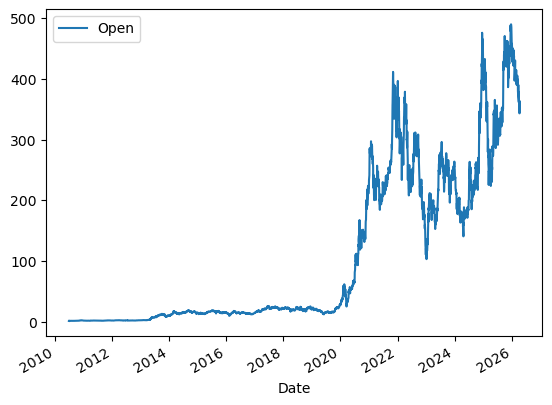

In [22]:
tsla_data.plot(x="Date", y="Open")

<Axes: xlabel='Date'>

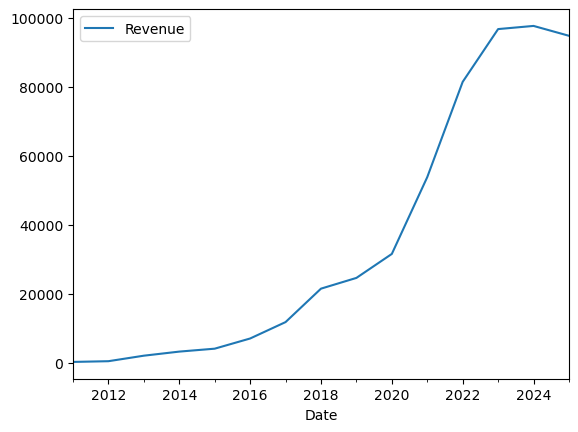

In [24]:
tsla_revenue.plot(x="Date", y="Revenue")

<Axes: xlabel='Date'>

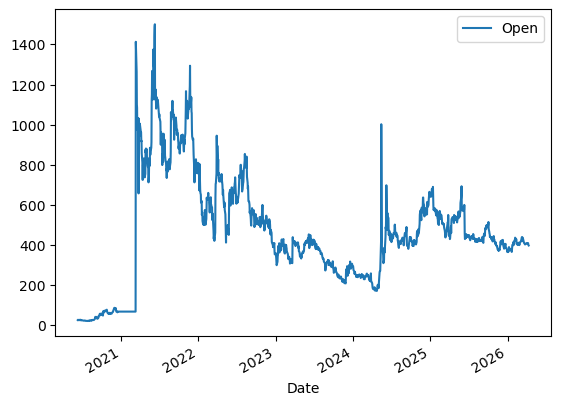

In [26]:
gme_data.plot(x="Date", y="Open")

<Axes: xlabel='Date'>

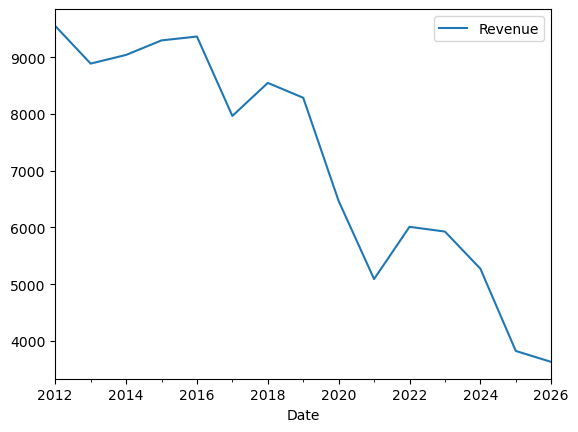

In [28]:
gme_revenue.plot(x="Date", y="Revenue")